In [1]:
#using PlotlyJS
using UMAP: umap
using Plots

include("../src/fxio.jl")
include("../src/kabsch_umeyama.jl")

vtor (generic function with 1 method)

In [2]:
f = open("../data/dssp.csv") 
dssp = Dict()
for line in readlines(f) 
    key_seq = split(line, ",")
    dssp[key_seq[1]] = key_seq[2]
end


In [153]:
function pdb2vtors(pdbpath)
    seqxyz = pdb2seqxyz(pdbpath)
    kmers = coords2kmers(seqxyz, 4, "ca")

    vtors = zeros(Float64, length(kmers), 3)
    
    for (i, kmer) in enumerate(kmers)
        vtors[i,1:3] = vtor(kmer[:,2:4])
    end
    
    return vtors
end


pdb2vtors (generic function with 1 method)

In [ ]:
seq2kmers

seq2kmers (generic function with 2 methods)

In [167]:
pdbpath = "../../scop40NR/d3wfwa1.ent"
id = basename(pdbpath)[1:end-4]
dssp4mers = seq2kmers(dssp[id], 4)

function convertdssp(dssp4mer)

    for i in 1:length(dssp4mer)
        if contains(dssp4mer[i], "HHH")
            dssp4mer[i] = "H"
        elseif  contains(dssp4mer[i], "EEE")
            dssp4mer[i] = "E"
        elseif  contains(dssp4mer[i], "TTT")
            dssp4mer[i] = "T"
        else 
            dssp4mer[i] = "C"
        end
    end
    return dssp4mer
end

convertdssp(dssp4mers)


130-element Vector{SubString{String}}:
 "C"
 "C"
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"
 ⋮
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"
 "H"

In [6]:
hcat(virtorses...)

3×190 Matrix{Float64}:
 91.4734  168.461   97.6207  -151.08    …  -165.454   -176.144   179.753
 53.2881   68.6452  83.129     44.4712       61.7402    59.5713   58.9319
 59.959    78.6724  85.3073    89.5514       50.5616    44.7704   53.5014

In [ ]:
umap_model = umap(hcat(virtorses...); n_neighbors=10, min_dist=0.001, n_epochs=200)


UndefVarError: UndefVarError: `virtorses` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

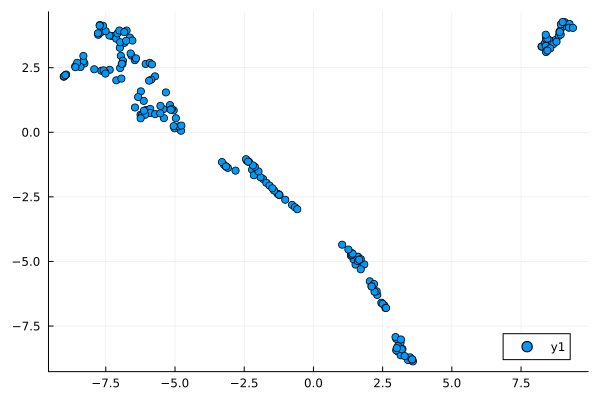

In [8]:
scatter(umap_model[1,:], umap_model[2,:])

In [ ]:
function catrace(seqxyz)

    trace_points = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="markers+text",
            marker=attr(size=2, color="red"),
            text=seqxyz[:,1],
            textposition="top center"
        )

    trace_lines = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="lines",
            line=attr(width=4, color="blue")
        )
        
    layout = Layout(
            title="Dihedral Angle Visualization",
            width=800,    # Set plot width
            height=600,   # Set plot height
            scene=attr(
                xaxis=attr(visible=false),
                yaxis=attr(visible=false),
                zaxis=attr(visible=false),
                camera=attr(
                    projection=attr(type="orthographic")  # Set perspective view
                )
            )
        )

    return plot([trace_lines, trace_points], layout)
end

catrace(seqxyz)